## Importig Libraries

In [1]:
import torch
from torch import nn
import torchvision
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader

import os
import matplotlib.pyplot as plt



In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


# Getting Dataset

In [3]:
import kagglehub

# Download latest version
spec_path = kagglehub.dataset_download("lokeshji/eatd-spec-final")

print("Path to dataset files:", spec_path)



Path to dataset files: /kaggle/input/eatd-spec-final


In [4]:
# Spectrogram Data Directory
IMG_SIZE = 224
transform = transforms.Compose(
    [transforms.Resize(size = (IMG_SIZE,IMG_SIZE)),
     transforms.TrivialAugmentWide(num_magnitude_bins=31),
     transforms.ToTensor()]
)



train_data_spec = datasets.ImageFolder(root ='/kaggle/input/eatd-spec-final/specs_final/train_spectrograms',
                                      transform = transform,
                                      target_transform =None)

test_data_spec = datasets.ImageFolder(root ='/kaggle/input/eatd-spec-final/specs_final/test_spectrograms',
                                      transform = transform,
                                      target_transform =None)
train_data_spec, test_data_spec

(Dataset ImageFolder
     Number of datapoints: 534
     Root location: /kaggle/input/eatd-spec-final/specs_final/train_spectrograms
     StandardTransform
 Transform: Compose(
                Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
                TrivialAugmentWide(num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 398
     Root location: /kaggle/input/eatd-spec-final/specs_final/test_spectrograms
     StandardTransform
 Transform: Compose(
                Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
                TrivialAugmentWide(num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
                ToTensor()
            ))

In [5]:
print(f"Total training samples: {len(train_data_spec)}")
print(f"Total testing samples: {len(test_data_spec)}")

Total training samples: 534
Total testing samples: 398


In [6]:
BATCH_SIZE = 1
NUM_OF_WORKERS = os.cpu_count()

train_loader = DataLoader(train_data_spec, 
                          batch_size=BATCH_SIZE, 
                          shuffle=True,
                         num_workers = NUM_OF_WORKERS)
test_loader = DataLoader(test_data_spec,
                         batch_size=BATCH_SIZE,
                         shuffle = False,
                        num_workers = NUM_OF_WORKERS)


### Visulaizing the data

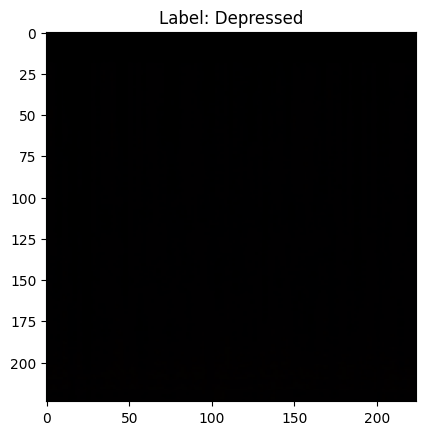

In [7]:
img, label = next(iter(train_loader))
plt.imshow(img[0].permute(1,2,0))
plt.title(f"Label: {'Depressed' if label[0].item() == 0 else 'Non-Depressed'}")  # Add label for context
plt.show()

# VIT: Overview
* Inputs: Images of Spectrogram and Tempogram
* Outputs: Image Classification Label
* Layers: Takes an input and manipulate it with a function
* Blocks: a collection of Layers
* Model:  A collection of Blocks

* **Embeddings**: Learnable Representation (Stats with random numbers and improve over time)

## 1. Split data into patches and creating the class, position and patch embedding
* Layers = input -> function -> output
* Input image: **H** x **W** x **C**
* Output image: ${N \times\left(P^2 \cdot C\right)}$
* H= Height
* W = Width
* C = color Channels
* P = Patch Size
* N = Number of Patches = (Height * width)/P^2
* D = constant Vector Size + embedding vector

In [8]:
height = 224
width = 224
Image_size = height * width
color_channels = 3
patch_size = 16
# calculating the number of patches
N = int((Image_size)/patch_size**2)
print(N)

196


In [9]:
# Input Shape
embeddinglayer_input_shape = (height, width, color_channels)
print(f'Input Shape: {embeddinglayer_input_shape}')

# output Shape
embedding_layer_output_shape = (N, patch_size**2 * color_channels)
print(f'Output Shape: {embedding_layer_output_shape}')


Input Shape: (224, 224, 3)
Output Shape: (196, 768)


## 2. Turning Images in to Patches

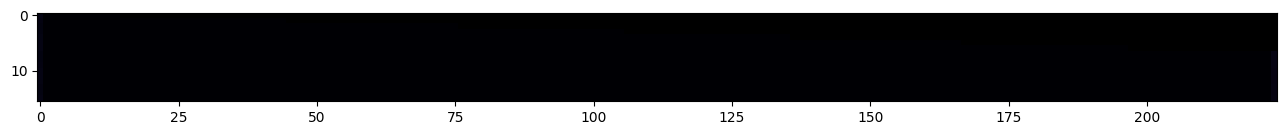

In [10]:
img, label = next(iter(train_loader))
PATCH_SIZE = 16
plt.figure(figsize = (PATCH_SIZE,PATCH_SIZE))
plt.imshow(img[0].permute(1,2,0)[:PATCH_SIZE, :, :])
plt.show()

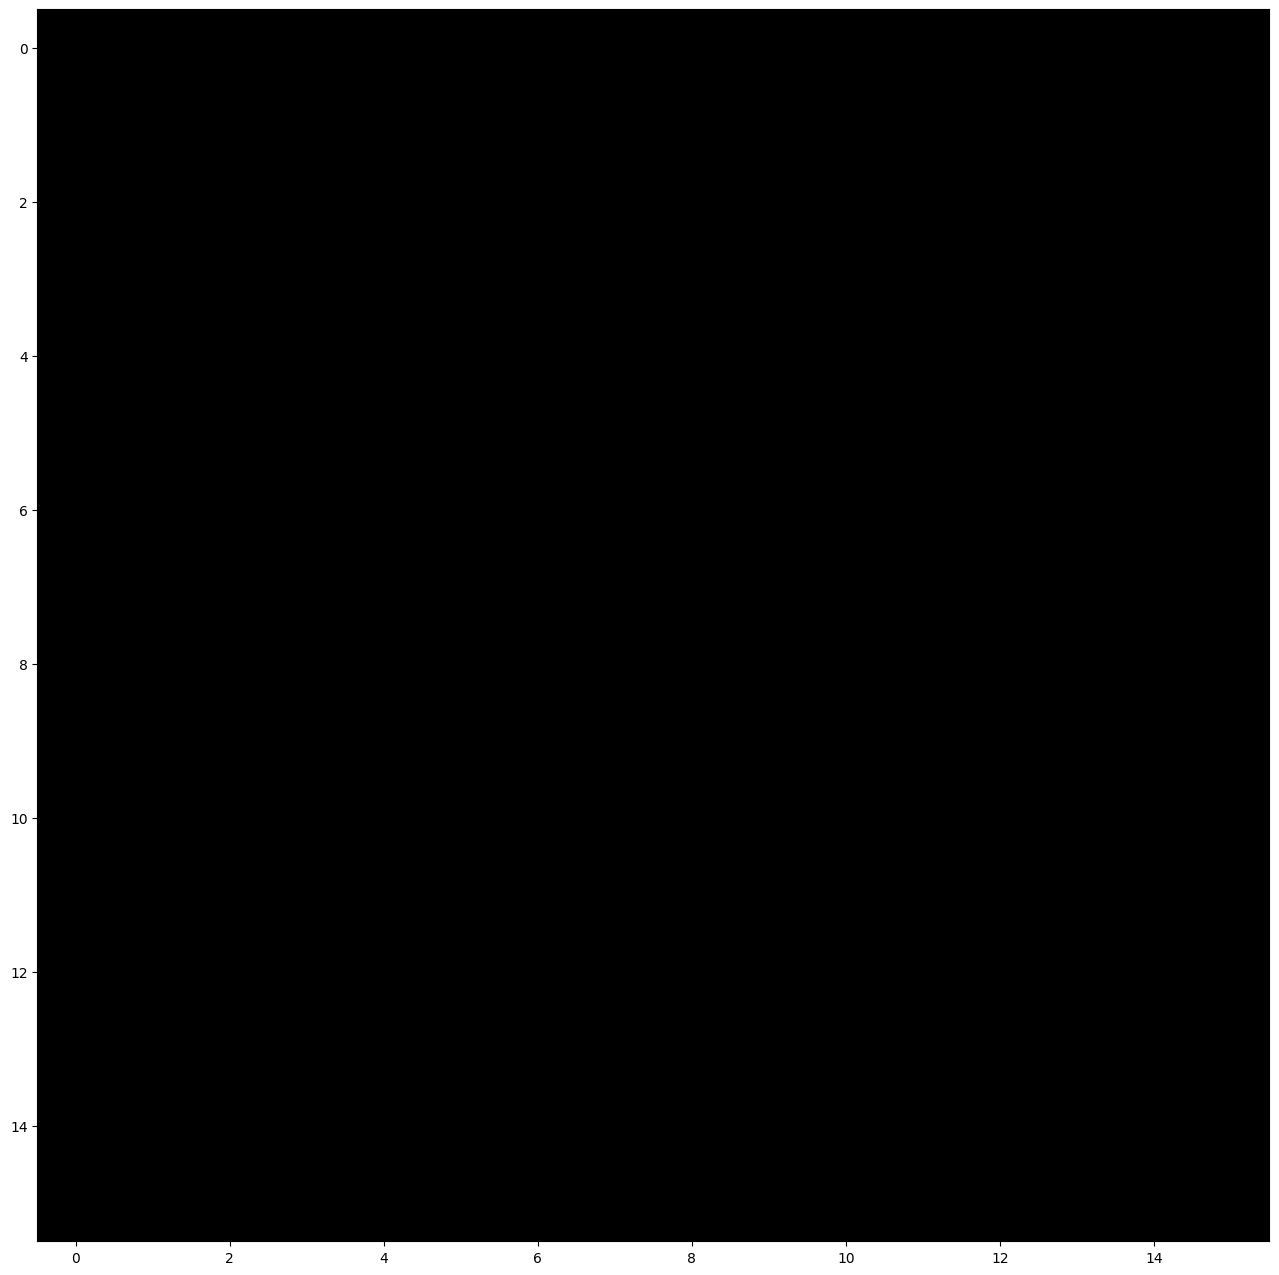

In [11]:
img, label = next(iter(train_loader))
PATCH_SIZE = 16
plt.figure(figsize = (PATCH_SIZE,PATCH_SIZE))
plt.imshow(img[0].permute(1,2,0)[:PATCH_SIZE, :PATCH_SIZE, :])
plt.show()

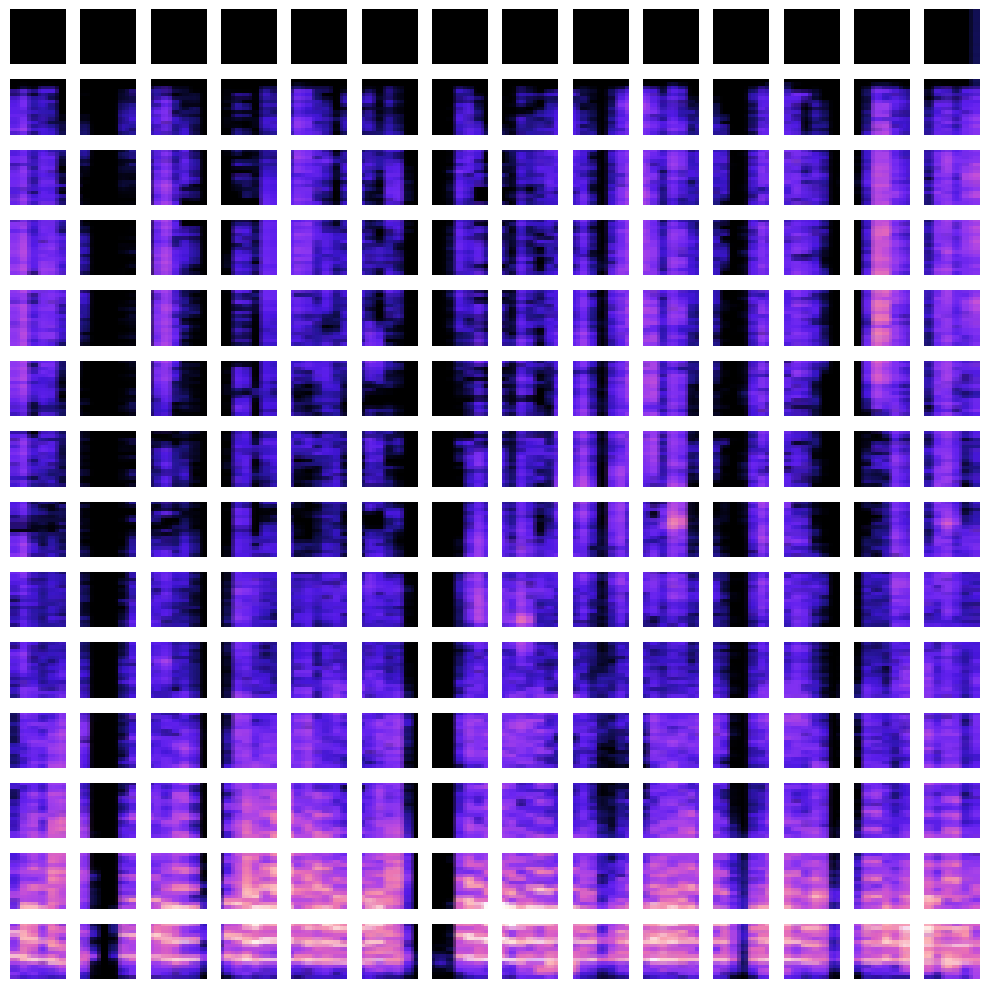

In [12]:
import matplotlib.pyplot as plt

img_size = 224
patch_size = 16

assert img_size % patch_size == 0
num_patches = img_size // patch_size

fig, axs = plt.subplots(nrows=num_patches,
                        ncols=num_patches,
                        figsize=(10, 10),
                        sharex=True,
                        sharey=True)

# Plotting each patch in the grid
for i, row in enumerate(range(0, img_size, patch_size)):
    for j, col in enumerate(range(0, img_size, patch_size)):
        patch = img[0].permute(1, 2, 0)[row:row+patch_size,# iterate throug h roes
        col:col+patch_size,# iterate through column
        :]
        axs[i, j].imshow(patch)
        axs[i, j].axis('off')

plt.tight_layout()
plt.show()


# 3. Patch to Embedding
Perhaps we could create the image patches and image patch embedidng is single step using `torch.nn.Conv2d()` by setting the kernel size and stride to `patch_size`

In [13]:
from torch import nn
patch_size = 16

conv2d = nn.Conv2d(in_channels = 3,# for coor images
                  out_channels = 768, # D size 
                  kernel_size = patch_size,
                  stride = patch_size,
                  padding = 0)
print(conv2d)

Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))


torch.Size([224, 224, 3])


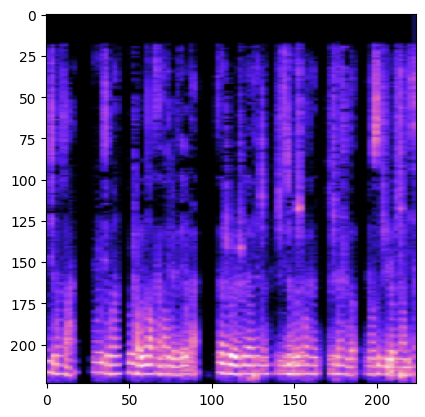

torch.Size([1, 3, 224, 224])
torch.Size([1, 768, 14, 14])


In [14]:
#3 passing image to conv2d
image = img[0].permute(1,2,0)
plt.imshow(image)
print(image.shape)
plt.show()
image1 = img[0].unsqueeze(0)
print(image1.shape)

image_to_conv = conv2d(image1)
print(image_to_conv.shape)

`torch.Size([1, 768, 14, 14])`-->> [batch_size, embeddong_dim, height, wiight]

In [15]:
# Flatten
flaten_layer = nn.Flatten(start_dim = 2, 
                         end_dim = 3)
print(flaten_layer(image_to_conv).shape)

torch.Size([1, 768, 196])


torch.Size([224, 224, 3])


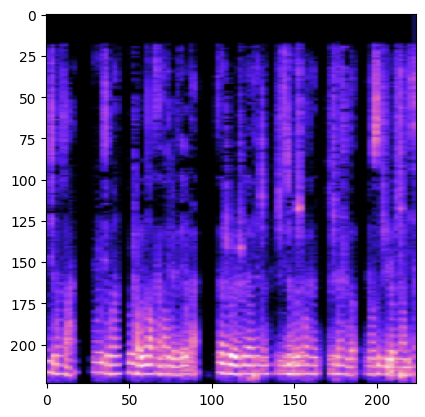

torch.Size([1, 768, 14, 14])
torch.Size([1, 768, 196])
torch.Size([1, 196, 768])


In [16]:
#3 passing image to conv2d
image = img[0].permute(1,2,0)
plt.imshow(image)
print(image.shape)
plt.show()

image_to_conv = conv2d(img[0].unsqueeze(0))
print(image_to_conv.shape)
# Flatten
flaten_layer = nn.Flatten(start_dim = 2, 
                         end_dim = 3)
print(flaten_layer(image_to_conv).shape)
# Rearranging output to use it as flatten 
image_ = flaten_layer(image_to_conv).permute(0,2,1)
print(image_.shape)


torch.Size([1, 196])


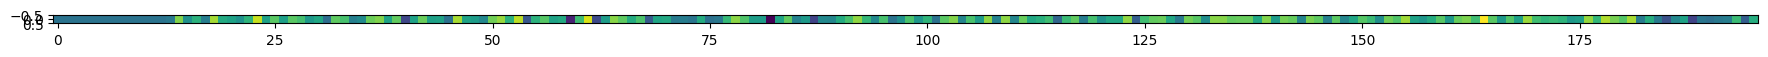

In [17]:
# Visualizing single embedding vetor of a patch
single_flatten_image = image_[:,:,0]
print(single_flatten_image.shape)
plt.figure(figsize=(22,22))
plt.imshow(single_flatten_image.detach().numpy())
plt.show()

## Turning ViT embedding layer into PyTorch module
* Create a class called PatchEmbedding which subclasses nn.Module (so it can be used a PyTorch layer).
* Initialize the class with the parameters in_channels=3, patch_size=16 (for ViT-Base) and embedding_dim=768 (this is $D$ for ViT-Base from Table 1).
* Create a layer to turn an image into patches using nn.Conv2d() (just like in 4.3 above).
* Create a layer to flatten the patch feature maps into a single dimension (just like in 4.4 above).
* Define a forward() method to take an input and pass it through the layers created in 3 and 4.
* Make sure the output shape reflects the required output shape of the ViT architecture (${N \times\left(P^{2} \cdot C\right)}$).

In [18]:
import torch
import torch.nn as nn

class PatchEmbedding(nn.Module):
    def __init__(self, 
                 in_channels=3,
                 patch_size=16,
                 embed_dim=768):
        super().__init__()
        
        self.patch_size = patch_size

        # Conv2d to extract non-overlapping patches and embed each one into a vector of size embed_dim
        self.patcher = nn.Conv2d(in_channels=in_channels,
                                 out_channels=embed_dim,
                                 kernel_size=patch_size,
                                 stride=patch_size,
                                 padding=0)

        # Flatten the spatial dimensions into one sequence length dimension
        self.flatten = nn.Flatten(start_dim=2, end_dim=3)

    def forward(self, x):
        # Ensure input image size is divisible by patch size
        image_resolution = x.shape[-1]
        assert image_resolution % self.patch_size == 0, \
            f"Image size {image_resolution} must be divisible by patch size {self.patch_size}"

        # Step 1: Apply conv to get patch embeddings
        x = self.patcher(x)  # [B, embed_dim, num_patches_H, num_patches_W]
        
        # Step 2: Flatten the spatial dimensions
        x = self.flatten(x)  # [B, embed_dim, num_patches]
        
        # Step 3: Permute to [B, num_patches, embed_dim]
        return x.permute(0, 2, 1)


In [19]:
torch.manual_seed(42)
patchify = PatchEmbedding( in_channels = 3,
                 patch_size = 16,
                 embed_dim = 768)
print(img.shape)
print(img[0].shape)
image = img[0].unsqueeze(0)
print(image.shape)
patch_embedded_image = patchify(image)
print(patch_embedded_image.shape)

torch.Size([1, 3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([1, 3, 224, 224])
torch.Size([1, 196, 768])


## creating class token embedding
* Class token embedding = shares the same size as the size of embedding dimention `D`

In [20]:
class_token = nn.Parameter(torch.randn(1,1,768), requires_grad = True)
class_token.shape

torch.Size([1, 1, 768])

In [21]:
#3 ADd class token to fron of patch embedding
patch_embedded_image_with_class_embedding = torch.cat((class_token, patch_embedded_image),
                                                     dim = 1)

print(patch_embedded_image_with_class_embedding)
print(patch_embedded_image_with_class_embedding.shape)

tensor([[[ 0.5436, -0.4700, -1.2133,  ..., -0.4571,  0.4486,  0.1217],
         [-0.0188, -0.0114, -0.0311,  ...,  0.0105, -0.0033,  0.0033],
         [-0.0188, -0.0114, -0.0311,  ...,  0.0105, -0.0033,  0.0033],
         ...,
         [-0.4503,  0.0717, -0.1291,  ...,  0.4066, -0.1837,  0.0844],
         [-0.6653,  0.1659, -0.0166,  ...,  0.4812, -0.2820,  0.1125],
         [-0.5384,  0.1112, -0.0266,  ...,  0.3525, -0.2760,  0.1634]]],
       grad_fn=<CatBackward0>)
torch.Size([1, 197, 768])


## Postional Embeddings
* Creating series of 1D learnable positional Embeddings and add them to sequence of pacth embeddings

In [22]:
print(patch_embedded_image_with_class_embedding)
print(patch_embedded_image_with_class_embedding.shape)

tensor([[[ 0.5436, -0.4700, -1.2133,  ..., -0.4571,  0.4486,  0.1217],
         [-0.0188, -0.0114, -0.0311,  ...,  0.0105, -0.0033,  0.0033],
         [-0.0188, -0.0114, -0.0311,  ...,  0.0105, -0.0033,  0.0033],
         ...,
         [-0.4503,  0.0717, -0.1291,  ...,  0.4066, -0.1837,  0.0844],
         [-0.6653,  0.1659, -0.0166,  ...,  0.4812, -0.2820,  0.1125],
         [-0.5384,  0.1112, -0.0266,  ...,  0.3525, -0.2760,  0.1634]]],
       grad_fn=<CatBackward0>)
torch.Size([1, 197, 768])


In [23]:
# calculate number of patches 
N = int((Image_size)/patch_size**2)
print(N)
embedding_dimenstion= patch_embedded_image_with_class_embedding.shape[-1]
print(embedding_dimenstion)

# Creating 1D Learnable Positinal embeddngs
postional_embeddings = nn.Parameter(torch.ones(1, N+1, embedding_dimenstion))
postional_embeddings , postional_embeddings.shape

196
768


(Parameter containing:
 tensor([[[1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          ...,
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.]]], requires_grad=True),
 torch.Size([1, 197, 768]))

In [24]:
# Add the postional Embeddings to the patch and class token embeddinsg
patch_and_postional_embeddings =patch_embedded_image_with_class_embedding + postional_embeddings
print(patch_and_postional_embeddings)
print(patch_and_postional_embeddings.shape)




tensor([[[ 1.5436,  0.5300, -0.2133,  ...,  0.5429,  1.4486,  1.1217],
         [ 0.9812,  0.9886,  0.9689,  ...,  1.0105,  0.9967,  1.0033],
         [ 0.9812,  0.9886,  0.9689,  ...,  1.0105,  0.9967,  1.0033],
         ...,
         [ 0.5497,  1.0717,  0.8709,  ...,  1.4066,  0.8163,  1.0844],
         [ 0.3347,  1.1659,  0.9834,  ...,  1.4812,  0.7180,  1.1125],
         [ 0.4616,  1.1112,  0.9734,  ...,  1.3525,  0.7240,  1.1634]]],
       grad_fn=<AddBackward0>)
torch.Size([1, 197, 768])


## Image->Patch embeddings -> postional Embedings = Patch Embedings + Postional Embeddings

torch.Size([1, 3, 224, 224])


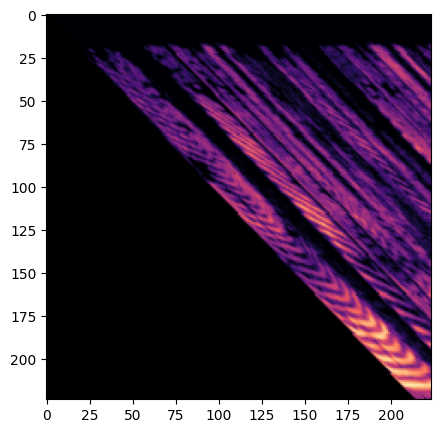

In [25]:
import torch
import torch.nn as nn

import matplotlib.pyplot as plt


patch_size = 16
embed_dim = 768

# Lets see the image
spec_img, label = next(iter(train_loader))

print(spec_img.shape)
plt.figure(figsize=(5, 5))
plt.imshow(spec_img[0].permute(1,2,0))
plt.show()


In [26]:
import torch
import torch.nn as nn

class PatchPosClassEmbeddings(nn.Module):
    def __init__(self, in_channels=3,
                 patch_size=16,
                 embed_dim=768,
                 image_size=224):
        super(PatchPosClassEmbeddings, self).__init__()

        self.patch_size = patch_size
        self.embed_dim = embed_dim
        self.numb_patches = (image_size // patch_size) ** 2

        self.patcher = nn.Conv2d(in_channels=in_channels,
                                 out_channels=embed_dim,
                                 kernel_size=patch_size,
                                 stride=patch_size)

        self.flatten = nn.Flatten(start_dim=2, end_dim=3)
        self.class_token = nn.Parameter(torch.ones(1, 1, embed_dim))
        self.pos_emb = nn.Parameter(torch.ones(1, self.numb_patches + 1, embed_dim))

    def forward(self, x):
        B = x.size(0)
        image_res = int(x.shape[-1])
        assert image_res % self.patch_size == 0, "Image size must be divisible by patch size"

        x_conv = self.patcher(x)              # [B, embed_dim, H', W']
        x_flat = self.flatten(x_conv)         # [B, embed_dim, N]
        x_perm = x_flat.permute(0, 2, 1)      # [B, N, embed_dim]

        cls_token = self.class_token.expand(B, -1, -1)    # [B, 1, embed_dim]
        x_cat = torch.cat([cls_token, x_perm], dim=1)     # [B, N+1, embed_dim]

        x_pos_patch = x_cat + self.pos_emb                # [B, N+1, embed_dim]
        return x_pos_patch


In [27]:
# Create an instance of your embedding module
embedding_model = PatchPosClassEmbeddings()

# Take a single spectrogram image from batch and add batch dimension
sq_img = spec_img[0].unsqueeze(0)  # Shape: [1, 3, 224, 224]
print(sq_img.shape)

# Pass it through the model
output_patch_pos_emb = embedding_model(sq_img)
print(output_patch_pos_emb.shape)  # Expected: [1, 197, 768] for 14x14 patches + 1 CLS token


torch.Size([1, 3, 224, 224])
torch.Size([1, 197, 768])


## Transformer Ecoder blocks
* Layer norm + MSA
* layer norm + MLP

### Multihead SelfAttention Block
* MultiHead Self Attention BLock
* LAyerNormalization

In [28]:
class MultiHEadSelfAttentionBlock(nn.Module):
    def __init__(self,
                embed_dim = 768,
                num_heads = 12,
                atn_dropout = 0):
        super(MultiHEadSelfAttentionBlock, self).__init__()
        # Creating Normalize Layer
        self.layer_norm = nn.LayerNorm(normalized_shape = embed_dim)

        # Creating Multihead self Attention
        self.multihead_atn = nn.MultiheadAttention(embed_dim = embed_dim,
                                          num_heads = num_heads,
                                          dropout = atn_dropout,
                                          batch_first = True)


    def forward(self,x):
        x_norm = self.layer_norm(x)
        atten_output,_ = self.multihead_atn(query = x_norm,
                                           key = x_norm,
                                           value = x_norm)
        return atten_output + x
        
        

In [29]:
MSA_block = MultiHEadSelfAttentionBlock()
print(f'Input to MSA: {output_patch_pos_emb.shape}')
# passing the patch and postion image embedding 
output_msa = MSA_block(output_patch_pos_emb)
print(f'Output to MSA: {output_msa.shape}')

Input to MSA: torch.Size([1, 197, 768])
Output to MSA: torch.Size([1, 197, 768])


### Multi Layer Perceptron BLock
x --> linear -> non-linear -> droput -> linear - > droput

In [30]:
class MLPBlock(nn.Module):
    def __init__(self,
                embed_dim = 768,
                mlp_size = 3072, # hidden unit size
                dropout = 0.1# from paper
                ):
        super().__init__()

        self.layer_norm = nn.LayerNorm(normalized_shape = embed_dim)
        # mlp layer
        self.mlp = nn.Sequential(
            nn.Linear(in_features = embed_dim,
                     out_features = mlp_size),
            nn.GELU(),
            nn.Dropout(p = dropout),
            nn.Linear(in_features = mlp_size,
                     out_features = embed_dim),
            nn.Dropout(p = dropout)
        )

    def forward(self, x):
        x_norm = self.layer_norm(x)
        x_mlp = self.mlp(x)
        return x_mlp
    

In [31]:
MSA_block = MultiHEadSelfAttentionBlock()
print(f'Input to MSA: {output_patch_pos_emb.shape}')
# passing the patch and postion image embedding 
output_msa = MSA_block(output_patch_pos_emb)
print(f'Output to MSA: {output_msa.shape}')

mlp_block = MLPBlock()
output_mlp = mlp_block(output_msa)
print(f'Output to MLP: {output_mlp.shape}')


Input to MSA: torch.Size([1, 197, 768])
Output to MSA: torch.Size([1, 197, 768])
Output to MLP: torch.Size([1, 197, 768])


In [32]:
# Create an instance of your embedding module
embedding_model = PatchPosClassEmbeddings()

# Take a single spectrogram image from batch and add batch dimension
sq_img = spec_img[0].unsqueeze(0)  # Shape: [1, 3, 224, 224]
print(sq_img.shape)

# Pass it through the model
output_patch_pos_emb = embedding_model(sq_img)
print(output_patch_pos_emb.shape)  # Expected: [1, 197, 768] for 14x14 patches + 1 CLS token


torch.Size([1, 3, 224, 224])
torch.Size([1, 197, 768])


# Transformer Encoder

In [33]:
class Encoder(nn.Module):
    def __init__(self,
                embed_dim = 768,
                num_heads = 12,# from paper
                mlp_size = 3072, # hidden unit size
                dropout = 0.1# from paper
                 ):
        super().__init__()
        # layer norm + MSA
        self.layer_norm = nn.LayerNorm(normalized_shape = embed_dim)
        self.multihead_atn = nn.MultiheadAttention(embed_dim = embed_dim,
                                          num_heads = num_heads,
                                          dropout = dropout,
                                          batch_first = True)
        # layer norm(already written above) +MLP
        self.mlp = nn.Sequential(
            nn.Linear(in_features = embed_dim,
                     out_features = mlp_size),
            nn.GELU(),
            nn.Dropout(p = dropout),
            nn.Linear(in_features = mlp_size,
                     out_features = embed_dim),
            nn.Dropout(p = dropout)
        )
        
    def forward(self,x):
        x_residul1 = x
        x_norm1 = self.layer_norm(x)
        x_msa_out,_ = self.multihead_atn(query = x_norm1,
                                       key = x_norm1, 
                                       value = x_norm1)  # adding residual connection
        x_residual2 = x_msa_out + x_residul1
        x_norm2 = self.layer_norm(x_msa_out)
        x_mlp_out = self.mlp(x_norm2) + x_residual2
        return x_mlp_out
        
        
    

In [34]:
t_encoder = Encoder()
out_encoder = t_encoder(output_patch_pos_emb)
print(out_encoder)
print(out_encoder.shape)

tensor([[[2.2785, 2.2071, 1.4352,  ..., 2.0718, 2.5092, 1.6536],
         [1.3331, 1.1621, 0.6067,  ..., 1.1142, 1.6805, 0.5392],
         [1.1245, 1.3557, 0.6995,  ..., 1.1241, 1.8210, 0.9388],
         ...,
         [0.9953, 1.2688, 0.4987,  ..., 1.1926, 1.5764, 0.8485],
         [1.3902, 1.3985, 0.7876,  ..., 1.2203, 1.6829, 1.1595],
         [0.8271, 2.1128, 1.1256,  ..., 0.8282, 1.9107, 0.8799]]],
       grad_fn=<AddBackward0>)
torch.Size([1, 197, 768])


In [35]:
from torchinfo import summary
model = Encoder()
summary(model,input_size =(1,197,768))


Layer (type:depth-idx)                   Output Shape              Param #
Encoder                                  [1, 197, 768]             --
├─LayerNorm: 1-1                         [1, 197, 768]             1,536
├─MultiheadAttention: 1-2                [1, 197, 768]             2,362,368
├─LayerNorm: 1-3                         [1, 197, 768]             (recursive)
├─Sequential: 1-4                        [1, 197, 768]             --
│    └─Linear: 2-1                       [1, 197, 3072]            2,362,368
│    └─GELU: 2-2                         [1, 197, 3072]            --
│    └─Dropout: 2-3                      [1, 197, 3072]            --
│    └─Linear: 2-4                       [1, 197, 768]             2,360,064
│    └─Dropout: 2-5                      [1, 197, 768]             --
Total params: 7,086,336
Trainable params: 7,086,336
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 4.73
Input size (MB): 0.61
Forward/backward pass size (MB): 8.47
Params size (MB)

## Complete Transformer using PyTorch

In [36]:
torch_transformer_encoder = nn.TransformerEncoderLayer(d_model = 768,# Embedding Dimention
                                                       nhead = 12,
                                                       dim_feedforward = 3072,
                                                       dropout = 0.1,
                                                       activation = 'gelu',
                                                       batch_first = True,
                                                       norm_first = True
                                                      )

In [37]:
from torchinfo import summary
summary(torch_transformer_encoder,input_size =(1,197,768))

Layer (type:depth-idx)                   Output Shape              Param #
TransformerEncoderLayer                  [1, 197, 768]             --
├─LayerNorm: 1-1                         [1, 197, 768]             1,536
├─MultiheadAttention: 1-2                [1, 197, 768]             2,362,368
├─Dropout: 1-3                           [1, 197, 768]             --
├─LayerNorm: 1-4                         [1, 197, 768]             1,536
├─Linear: 1-5                            [1, 197, 3072]            2,362,368
├─Dropout: 1-6                           [1, 197, 3072]            --
├─Linear: 1-7                            [1, 197, 768]             2,360,064
├─Dropout: 1-8                           [1, 197, 768]             --
Total params: 7,087,872
Trainable params: 7,087,872
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 4.73
Input size (MB): 0.61
Forward/backward pass size (MB): 8.47
Params size (MB): 18.90
Estimated Total Size (MB): 27.98

# Putting it all together: ViT

In [38]:
BATCH_SIZE = 1
NUM_OF_WORKERS = os.cpu_count()

train_loader = DataLoader(train_data_spec, 
                          batch_size=BATCH_SIZE, 
                          shuffle=True,
                         num_workers = NUM_OF_WORKERS)
test_loader = DataLoader(test_data_spec,
                         batch_size=BATCH_SIZE,
                         shuffle = False,
                        num_workers = NUM_OF_WORKERS)


### 1. Embedding Layer

In [39]:
import torch
import torch.nn as nn


class PatchPosClassEmbeddings(nn.Module):
    def __init__(self, in_channels=3,
                 patch_size=16,
                 embed_dim=768,
                 image_size=224):
        super(PatchPosClassEmbeddings, self).__init__()

        self.patch_size = patch_size
        self.embed_dim = embed_dim
        self.numb_patches = (image_size // patch_size) ** 2

        self.patcher = nn.Conv2d(in_channels=in_channels,
                                 out_channels=embed_dim,
                                 kernel_size=patch_size,
                                 stride=patch_size)

        self.flatten = nn.Flatten(start_dim=2, end_dim=3)
        self.class_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.pos_emb = nn.Parameter(torch.randn(1, self.numb_patches + 1, embed_dim))

    def forward(self, x):
        B = x.size(0)
        image_res = int(x.shape[-1])
        assert image_res % self.patch_size == 0, "Image size must be divisible by patch size"

        x_conv = self.patcher(x)              # [B, embed_dim, H', W']
        x_flat = self.flatten(x_conv)         # [B, embed_dim, N]
        x_perm = x_flat.permute(0, 2, 1)      # [B, N, embed_dim]

        cls_token = self.class_token.expand(B, -1, -1)    # [B, 1, embed_dim]
        x_cat = torch.cat([cls_token, x_perm], dim=1)     # [B, N+1, embed_dim]

        x_pos_patch = x_cat + self.pos_emb                # [B, N+1, embed_dim]
        return x_pos_patch


### 2. Transformer Encoder

In [40]:
class TransformerEncoder(nn.Module):
    def __init__(self,
                embed_dim = 768,
                num_heads = 12,# from paper
                mlp_size = 3072, # hidden unit size
                mlp_dropout = 0.1# from paper
                 ):
        super().__init__()
        # layer norm + MSA
        self.layer_norm = nn.LayerNorm(normalized_shape = embed_dim)
        self.multihead_atn = nn.MultiheadAttention(embed_dim = embed_dim,
                                                  num_heads = num_heads,
                                                  dropout = 0,
                                                  batch_first = True)
        # layer norm(already written above) +MLP
        self.mlp = nn.Sequential(
            nn.Linear(in_features = embed_dim,
                     out_features = mlp_size),
            nn.GELU(),
            nn.Dropout(p = mlp_dropout),
            nn.Linear(in_features = mlp_size,
                     out_features = embed_dim),
            nn.Dropout(p = mlp_dropout)
        )
        
    def forward(self,x):
        x_residul1 = x
        x_norm1 = self.layer_norm(x)
        x_msa_out,_ = self.multihead_atn(query = x_norm1,
                                       key = x_norm1, 
                                       value = x_norm1)  # adding residual connection
        x_msa_out_with_res = x_msa_out + x_residul1
        x_residual2 =  x_msa_out_with_res
        x_norm2 = self.layer_norm(x_msa_out_with_res)
        x_mlp_out_res = self.mlp(x_norm2) + x_residual2
        return x_mlp_out_res
        
        
    

In [41]:
class Vit(nn.Module):
    def __init__(self,
                img_size: int=224,
                in_channels: int = 3,
                patch_size : int = 16,
                num_transformer_layer: int = 12,
                embed_dim: int = 768,
                mlp_size : int = 3072,
                num_heads: int = 12,
                atn_dropout: int = 0,
                mlp_dropout: int = 0.1,
                embed_dropout: int = 0.1,
                num_classes : int = 1000):
        super().__init__()
        # make assertion for image size
        assert img_size % patch_size == 0
        # Calculating number of patchs
        self.N = (img_size*img_size)// patch_size**2

        #Embedding Droput
        self.embedding_droput = nn.Dropout(p = embed_dropout )

        # Patch_embedding
        self.patch_embediing = PatchPosClassEmbeddings(in_channels = in_channels,
                                                        patch_size=patch_size,
                                                        embed_dim=embed_dim,
                                                        image_size=img_size)
        # Transformer encoder block
        self.transformer_encoder = nn.Sequential(*[TransformerEncoder(
                                                    embed_dim = 768,
                                                    num_heads = num_heads,# from paper
                                                    mlp_size = mlp_size, # hidden unit size
                                                    mlp_dropout = mlp_dropout# from paper
                                                    ) for _ in range(num_transformer_layer)])
        # creating classifier head
        self.classifier = nn.Sequential(
            nn.LayerNorm(normalized_shape = embed_dim),
            nn.Linear(in_features = embed_dim,
                     out_features = num_classes)
            
        )

    def forward(self, x):
        x = self.patch_embediing(x)
        x = self.embedding_droput(x)
        x = self.transformer_encoder(x)
        # put 0th index logit through classifier()
        x = self.classifier(x[:,0])
        return x

In [42]:
from torchinfo import summary
model = Vit(num_classes = 2) 
summary(model,input_size = (1,3,224,224))

Layer (type:depth-idx)                   Output Shape              Param #
Vit                                      [1, 2]                    --
├─PatchPosClassEmbeddings: 1-1           [1, 197, 768]             152,064
│    └─Conv2d: 2-1                       [1, 768, 14, 14]          590,592
│    └─Flatten: 2-2                      [1, 768, 196]             --
├─Dropout: 1-2                           [1, 197, 768]             --
├─Sequential: 1-3                        [1, 197, 768]             --
│    └─TransformerEncoder: 2-3           [1, 197, 768]             --
│    │    └─LayerNorm: 3-1               [1, 197, 768]             1,536
│    │    └─MultiheadAttention: 3-2      [1, 197, 768]             2,362,368
│    │    └─LayerNorm: 3-3               [1, 197, 768]             (recursive)
│    │    └─Sequential: 3-4              [1, 197, 768]             4,722,432
│    └─TransformerEncoder: 2-4           [1, 197, 768]             --
│    │    └─LayerNorm: 3-5               [1, 197,

### Training the model
* optmizer : Adam (beta1, beta2 = 0.8, 0.999; weightdecay = 0.1)

In [46]:
# Optimizer
optimizer = torch.optim.Adam(params =model.parameters(),
                             lr = 0.001,
                             betas = (0.9, 0.999),
                             weight_decay = 0.1
                            )
# Loss Function
criterion = nn.CrossEntropyLoss()



In [47]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define model
model = Vit(img_size=224, in_channels=3, num_classes=2)  # 2 classes: depressed & non_depressed
model.to(device)

# Training function
def train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs=10):
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct_preds = 0
        total_samples = 0

        loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}]", leave=False)

        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Stats
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_samples += labels.size(0)
            correct_preds += (predicted == labels).sum().item()

            loop.set_postfix(loss=loss.item(), acc=100. * correct_preds / total_samples)

        # Validation
        val_acc, val_loss = evaluate_model(model, test_loader, criterion)
        print(f"Epoch [{epoch+1}/{num_epochs}] ✅ Train Acc: {100 * correct_preds / total_samples:.2f}%, Val Acc: {val_acc:.2f}%, Val Loss: {val_loss:.4f}")

# Evaluation function
def evaluate_model(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    avg_loss = total_loss / len(loader)
    return accuracy, avg_loss


In [48]:
train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs=10)


Epoch [1/10] ✅ Train Acc: 53.00%, Val Acc: 49.75%, Val Loss: 0.6938


Epoch [2/10] ✅ Train Acc: 58.24%, Val Acc: 49.75%, Val Loss: 0.6938


Epoch [3/10] ✅ Train Acc: 54.87%, Val Acc: 49.75%, Val Loss: 0.6943


Epoch [4/10] ✅ Train Acc: 55.43%, Val Acc: 49.75%, Val Loss: 0.6930


Epoch [5/10] ✅ Train Acc: 55.62%, Val Acc: 49.75%, Val Loss: 0.6928


Epoch [6/10] ✅ Train Acc: 50.00%, Val Acc: 49.75%, Val Loss: 0.6930


Epoch [7/10] ✅ Train Acc: 54.12%, Val Acc: 49.75%, Val Loss: 0.6935


Epoch [8/10] ✅ Train Acc: 59.55%, Val Acc: 49.75%, Val Loss: 0.6918


Epoch [9/10] ✅ Train Acc: 55.62%, Val Acc: 49.75%, Val Loss: 0.6925


Epoch [10/10] ✅ Train Acc: 53.18%, Val Acc: 49.75%, Val Loss: 0.6926
